In [86]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [87]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [89]:
full_dataset = torch.from_numpy(full_dataset)
full_dataset = full_dataset.to(torch.float32)

In [90]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.conv_ae import ConvAE

checkpoint = torch.load(f"{CHECKPOINT_DIR}/conv_autoenc_v1.pth", map_location="cpu")

config = checkpoint["config"]

model = ConvAE()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

ConvAE(
  (encoder): Sequential(
    (0): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (10): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Conv1d(1, 1, kernel_size=(3,), stride=(2,), padding=(1,))
    (16): BatchNorm1d(1, eps=1e-05, mom

In [91]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model consists of", trainable_params, "trainable parameters.")

Model consists of 8712 trainable parameters.


In [92]:
# TODO: move it somewhere to autoencoders or sht
def score_points(pts, model, criterion=None):
    import torch
    if not criterion:
        import torch
        criterion = torch.nn.MSELoss()

    out_scores = []
    for out in pts:
        out = torch.tensor(out).to(torch.float32)
        out = out.reshape(1, 1, 96)
        pred = model(out).detach()
        loss = criterion(pred, out).detach().numpy()
        out_scores.append(loss)
        
    return out_scores

In [93]:
scores = score_points(full_dataset, model)

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_22256\2640477512.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(torch.float32)


In [94]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))

In [95]:
eval_score = score_points(eval_df['histogram'], model)

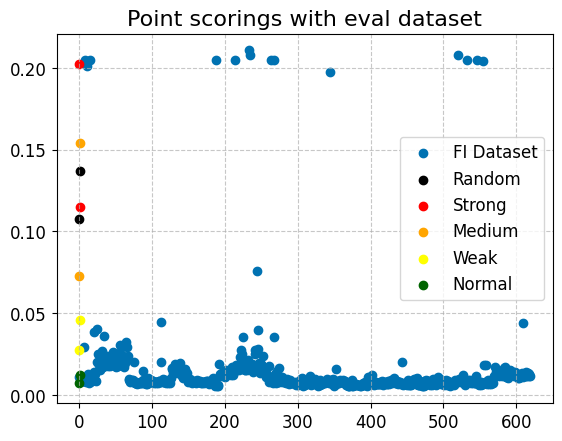

In [96]:
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.title("Point scorings with eval dataset")
plt.scatter(range(len(scores)), scores, label='FI Dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.legend()

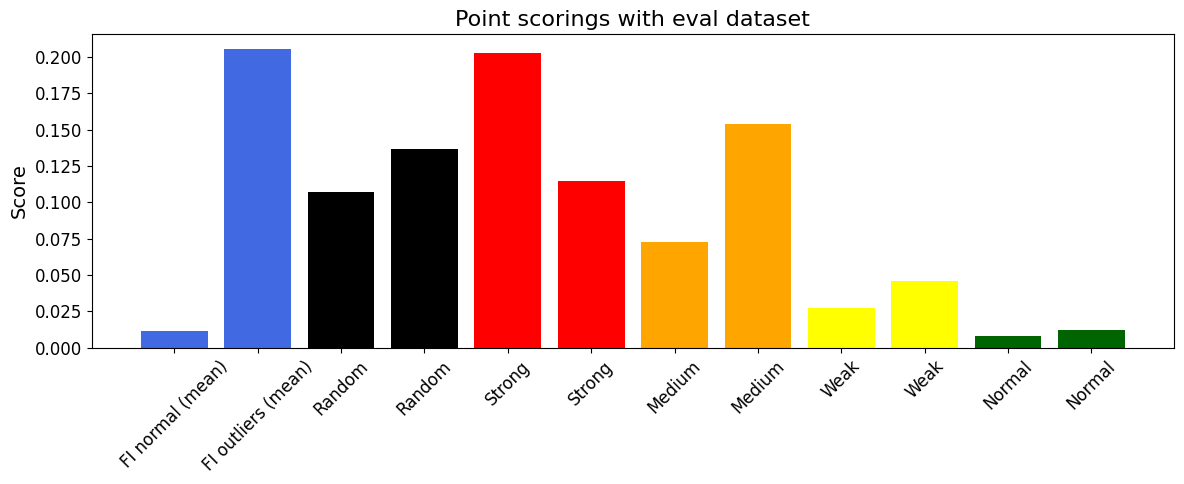

In [97]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.array(scores)
eval_score = np.array(eval_score)

fi_above = scores[scores > 0.2]
fi_below = scores[scores <= 0.2]

fi_above_mean = fi_above.mean() if len(fi_above) else 0
fi_below_mean = fi_below.mean() if len(fi_below) else 0

values = [fi_below_mean, fi_above_mean]
colors = ["royalblue", "royalblue"]
labels = ["FI normal (mean)", "FI outliers (mean)"]

group_colors = ["black", "red", "orange", "yellow", "darkgreen"]
group_labels = ["Random", "Strong", "Medium", "Weak", "Normal"]

for i in range(0, len(eval_score), 2):
    pair = eval_score[i:i+2]
    group_idx = i // 2
    
    for val in pair:
        values.append(val)
        colors.append(group_colors[group_idx])
        labels.append(group_labels[group_idx])

plt.figure(figsize=(12, 5))
plt.title("Point scorings with eval dataset")

x = np.arange(len(values))
plt.bar(x, values, color=colors)

plt.xticks(x, labels, rotation=45)
plt.ylabel("Score")

plt.tight_layout()
plt.show()